# Exercise 13
**Cristina Correa - 1819211867**


In real world scenarios we are usually very keen to use the classifiers to identify
the most important features which can be important to the medical experts and might lead to
new discoveries and a better understanding of the field. Thus, we can visualise the feature
importance as follows

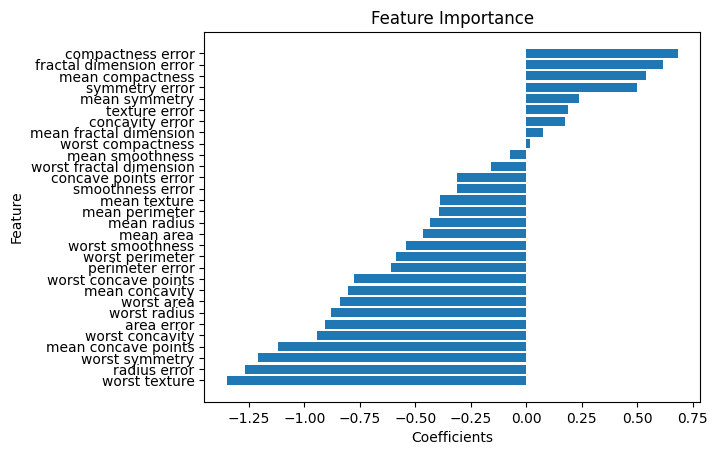

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)

from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

classifier = LogisticRegression(random_state=0, max_iter=200)
classifier.fit(X_train_scaled, y_train)

# Predicting the test set results
y_pred = classifier.predict(X_test)

# Plotting feature importance
coefficients = classifier.coef_[0]
sorted_indices = np.argsort(coefficients)
plt.barh(
    range(len(coefficients)),
    coefficients[sorted_indices],
    tick_label=feature_names[sorted_indices],
)
plt.title("Feature Importance")
plt.xlabel("Coefficients")
plt.ylabel("Feature")
plt.show()